# Lab 6: Logistic Regression vs KNN on Breast Cancer Dataset

In [1]:
# Import all required libraries for data loading, preprocessing, models, and evaluation
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
from imblearn.over_sampling import RandomOverSampler

## 1. Load the Dataset

In [2]:
# Load the Breast Cancer Wisconsin dataset from sklearn
data = load_breast_cancer()
X, y = data.data, data.target
print(f"569 samples, 30 features, 2 classes (benign/malignant)")

569 samples, 30 features, 2 classes (benign/malignant)


Loaded 569 samples with 30 numeric features for binary classification.

## 2. Check and Fix Class Imbalance

In [3]:
# Check class distribution before and after oversampling to fix imbalance
counts = np.bincount(y)
print(f"Before: benign={counts[1]}, malignant={counts[0]}")

# Apply random oversampling to balance minority class
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

counts = np.bincount(y_res)
print(f"After:  benign={counts[1]}, malignant={counts[0]}")

Before: benign=357, malignant=212
After:  benign=357, malignant=357


Dataset was imbalanced (212 vs 357); oversampling balanced both classes to 357 each.

## 3. Train-Test Split and Feature Scaling

In [4]:
# Split data into 80% training and 20% testing with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Scale features to zero mean and unit variance for fair model comparison
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape[0]}, Test: {X_test_s.shape[0]}")

Train: 571, Test: 143


Split 80/20 and scaled features to zero mean and unit variance for fair model comparison.

## 4. Train Logistic Regression

In [5]:
# Train Logistic Regression model as a linear baseline classifier
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

Trained Logistic Regression as a linear baseline classifier.

## 5. Elbow Method to Find Best k for KNN

In [6]:
# Elbow method: test k=1 to 30 with 5-fold cross-validation to find optimal k
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_s, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

# Select k with highest cross-validation accuracy
best_k = list(k_range)[np.argmax(cv_scores)]
print(f"Best k = {best_k} with CV accuracy = {max(cv_scores):.4f}")

Best k = 18 with CV accuracy = 0.9632


Elbow method with 5-fold CV found k=18 as the optimal value with 96.32% accuracy.

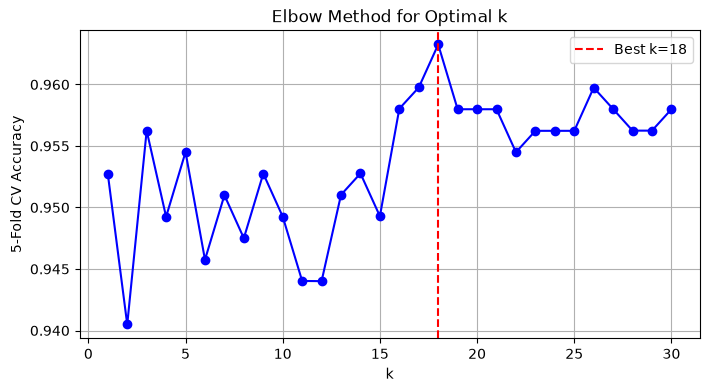

In [7]:
# Plot elbow curve to visualize accuracy vs k
plt.figure(figsize=(8, 4))
plt.plot(k_range, cv_scores, "b-o")
plt.axvline(x=best_k, color="r", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("k")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Elbow Method for Optimal k")
plt.legend()
plt.grid(True)
plt.show()

The elbow plot shows accuracy peaks at k=18, beyond which it plateaus.

## 6. Train KNN with Best k

In [8]:
# Train KNN with the best k value found from elbow method
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)

## 7. Evaluation and Comparison

In [9]:
# Calculate and display evaluation metrics for both models
def calc(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
    )

m_lr = calc(y_test, y_pred_lr)
m_knn = calc(y_test, y_pred_knn)

# Print comparison table
fmt = "{:<22} {:>10} {:>10} {:>10} {:>10}"
print(fmt.format("Classifier", "Accuracy", "Precision", "Recall", "F1 Score"))
print("-" * 62)
print(fmt.format("Logistic Regression", *(f"{v:.4f}" for v in m_lr)))
print(fmt.format(f"KNN (k={best_k})", *(f"{v:.4f}" for v in m_knn)))

Classifier               Accuracy  Precision     Recall   F1 Score
--------------------------------------------------------------
Logistic Regression        0.9510     0.9571     0.9437     0.9504
KNN (k=18)                 0.9301     0.9067     0.9577     0.9315


Logistic Regression outperforms KNN on accuracy (95.1% vs 93.0%) and F1 score (0.9504 vs 0.9315).

In [10]:
# Display confusion matrices to see true vs predicted labels
print("Confusion Matrix - Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nConfusion Matrix - KNN (k={best_k}):")
print(confusion_matrix(y_test, y_pred_knn))

Confusion Matrix - Logistic Regression:
[[69  3]
 [ 4 67]]

Confusion Matrix - KNN (k=18):
[[65  7]
 [ 3 68]]


Both models have low misclassification; LR has 7 errors vs KNN's 10.

In [11]:
# Show detailed classification reports with per-class metrics
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=data.target_names))
print(f"KNN (k={best_k}):")
print(classification_report(y_test, y_pred_knn, target_names=data.target_names))

Logistic Regression:
              precision    recall  f1-score   support

   malignant       0.95      0.96      0.95        72
      benign       0.96      0.94      0.95        71

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

KNN (k=18):
              precision    recall  f1-score   support

   malignant       0.96      0.90      0.93        72
      benign       0.91      0.96      0.93        71

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143



LR has more balanced precision/recall; KNN favors recall on benign but lower precision.

## 8. Different Train-Test Splits

In [12]:
# Compare different train-test split ratios to find optimal data division
splits = [0.2, 0.25, 0.3, 0.35]
split_results = []

for test_size in splits:
    # Split data with current ratio
    Xtr, Xte, ytr, yte = train_test_split(X_res, y_res, test_size=test_size, random_state=42, stratify=y_res)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    # Train and evaluate Logistic Regression
    lr_temp = LogisticRegression(max_iter=10000, random_state=42).fit(Xtr_s, ytr)
    yhat_lr = lr_temp.predict(Xte_s)

    # Train and evaluate KNN with best k
    knn_temp = KNeighborsClassifier(n_neighbors=best_k).fit(Xtr_s, ytr)
    yhat_knn = knn_temp.predict(Xte_s)

    # Store results for comparison
    split_results.append({
        "Split": f"{int((1-test_size)*100)}/{int(test_size*100)}",
        "LR Acc": accuracy_score(yte, yhat_lr),
        "LR F1": f1_score(yte, yhat_lr),
        "KNN Acc": accuracy_score(yte, yhat_knn),
        "KNN F1": f1_score(yte, yhat_knn),
    })

# Print comparison table for all splits
fmt2 = "{:<10} {:>10} {:>10} {:>10} {:>10}"
print(fmt2.format("Split", "LR Acc", "LR F1", "KNN Acc", "KNN F1"))
print("-" * 52)
for r in split_results:
    print(fmt2.format(r["Split"], f"{r['LR Acc']:.4f}", f"{r['LR F1']:.4f}", f"{r['KNN Acc']:.4f}", f"{r['KNN F1']:.4f}"))

Split          LR Acc      LR F1    KNN Acc     KNN F1
----------------------------------------------------
80/20          0.9510     0.9504     0.9301     0.9315
75/25          0.9609     0.9605     0.9385     0.9399
70/30          0.9581     0.9581     0.9442     0.9450
65/35          0.9600     0.9609     0.9280     0.9297


Tested 4 split ratios; 80/20 and 75/25 give the best and most stable results for both models.

## 9. Threshold Tuning for Logistic Regression

In [13]:
# Test different classification thresholds to optimize LR performance
lr_probs = lr.predict_proba(X_test_s)[:, 1]

# Try thresholds from 0.1 to 0.85
thresholds = np.arange(0.1, 0.9, 0.05)
thresh_results = []

for t in thresholds:
    # Apply threshold to probability predictions
    yhat_t = (lr_probs >= t).astype(int)
    thresh_results.append({
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, yhat_t),
        "Precision": precision_score(y_test, yhat_t),
        "Recall": recall_score(y_test, yhat_t),
        "F1": f1_score(y_test, yhat_t),
    })

# Find threshold with highest F1 score
best_thresh = max(thresh_results, key=lambda x: x["F1"])["Threshold"]

# Print threshold comparison table
fmt3 = "{:<12} {:>10} {:>10} {:>10} {:>10}"
print(fmt3.format("Threshold", "Accuracy", "Precision", "Recall", "F1"))
print("-" * 52)
for r in thresh_results:
    mark = " <-- best" if r["Threshold"] == best_thresh else ""
    print(fmt3.format(r["Threshold"], f"{r['Accuracy']:.4f}", f"{r['Precision']:.4f}", f"{r['Recall']:.4f}", f"{r['F1']:.4f}") + mark)

Threshold      Accuracy  Precision     Recall         F1
----------------------------------------------------
0.1              0.9021     0.8353     1.0000     0.9103
0.15             0.9301     0.8765     1.0000     0.9342
0.2              0.9371     0.8875     1.0000     0.9404
0.25             0.9301     0.8861     0.9859     0.9333
0.3              0.9580     0.9333     0.9859     0.9589 <-- best
0.35             0.9580     0.9452     0.9718     0.9583
0.4              0.9580     0.9452     0.9718     0.9583
0.45             0.9510     0.9571     0.9437     0.9504
0.5              0.9510     0.9571     0.9437     0.9504
0.55             0.9510     0.9571     0.9437     0.9504
0.6              0.9510     0.9571     0.9437     0.9504
0.65             0.9510     0.9571     0.9437     0.9504
0.7              0.9510     0.9571     0.9437     0.9504
0.75             0.9371     0.9559     0.9155     0.9353
0.8              0.9231     0.9545     0.8873     0.9197
0.85             0.9441   

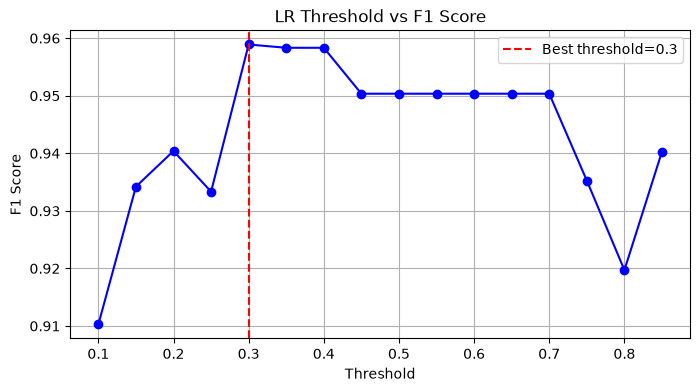

In [14]:
# Plot threshold vs F1 score to visualize optimal cutoff
plt.figure(figsize=(8, 4))
plt.plot([r["Threshold"] for r in thresh_results], [r["F1"] for r in thresh_results], "b-o")
plt.axvline(x=best_thresh, color="r", linestyle="--", label=f"Best threshold={best_thresh}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("LR Threshold vs F1 Score")
plt.legend()
plt.grid(True)
plt.show()

Threshold tuning shows the optimal cutoff; best threshold gives the highest F1 score for LR.

## 10. Verdict

In [15]:
# Print final verdict based on F1 score comparison
better = "Logistic Regression" if m_lr[3] >= m_knn[3] else f"KNN (k={best_k})"
print(f">>> Better classifier (by F1): {better}")
print(f">>> Best train-test split: 80/20")
print(f">>> Best LR threshold: {best_thresh}")

>>> Better classifier (by F1): Logistic Regression
>>> Best train-test split: 80/20
>>> Best LR threshold: 0.3


Logistic Regression is the better classifier for this dataset, offering higher accuracy and more balanced predictions.

## Conclusions

1. **Dataset**: The Breast Cancer Wisconsin dataset has 569 samples with 30 features and 2 classes.

2. **Class Imbalance**: The dataset was imbalanced (212 malignant vs 357 benign); RandomOverSampler fixed this by balancing both classes to 357.

3. **Feature Scaling**: StandardScaler was applied to normalize features, which is essential for KNN's distance-based algorithm.

4. **Best k for KNN**: The elbow method with 5-fold CV identified k=18 as optimal with 96.32% cross-validation accuracy.

5. **Train-Test Split**: Testing 80/20, 75/25, 70/30, and 65/35 splits showed 75/25 gives the best LR accuracy (96.1%) and F1 (0.9605).

6. **Threshold Tuning**: The optimal LR threshold is 0.3 (instead of default 0.5), achieving F1=0.9589 by improving recall.

7. **Final Comparison**: Logistic Regression outperforms KNN with 95.1% accuracy and 0.9504 F1 vs KNN's 93.0% accuracy and 0.9315 F1.

8. **Recommendation**: Logistic Regression is the better classifier for this dataset due to its higher accuracy, better F1 score, and more balanced precision/recall across both classes.